In [1]:
## Python single cell stack


import scanpy as sc

import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse import issparse

## Plotting

import matplotlib.pyplot as plt
import seaborn as sns

## Paths and system

import os, sys


In [2]:
os.chdir('../../analysis')

d2_dz_clustered = sc.read_h5ad('clustered_egfDuod_D2_DZ.h5ad')

In [3]:
d2_dz_clustered

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

#### Inspect our leiden clustering metadata

In [4]:
d2_dz_clustered.obs['leiden'].head()

AAACCAAAGATACTCG-1    11
AAACCAAAGCCAACTA-1     2
AAACCAAAGGCACACT-1     2
AAACCAAAGGTGCTCG-1     4
AAACCAAAGTCAACTG-1     5
Name: leiden, dtype: category
Categories (24, object): ['0', '1', '2', '3', ..., '20', '21', '22', '23']

### Create a new metadata column


In [5]:

d2_dz_clustered.obs['manual_labelled'] = d2_dz_clustered.obs['leiden'].copy()

#### Manually change the new labels to ISC, and also Proliferating PCs


In [6]:

d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '0', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '1', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '2', 'manual_label'] = 'PCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '3', 'manual_label'] = 'Enterocytes'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '4', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '5', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '6', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '7', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '8', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '9', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '10', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '11', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '12', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '13', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '14', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '15', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '16', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '17', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '18', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '19', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '20', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '21', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '22', 'manual_label'] = 'ISCs'
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['leiden'] == '23', 'manual_label'] = 'ISCs'



### Ensure the type is categorical for plotting, and inspect the metadata head

In [7]:
d2_dz_clustered.obs['manual_label'] = d2_dz_clustered.obs['manual_label'].astype('category')


In [8]:
d2_dz_clustered.obs[['leiden', 'manual_label']].head(10)


,leiden,manual_label
AAACCAAAGATACTCG-1,11,ISCs
AAACCAAAGCCAACTA-1,2,PCs
AAACCAAAGGCACACT-1,2,PCs
AAACCAAAGGTGCTCG-1,4,ISCs
AAACCAAAGTCAACTG-1,5,ISCs
AAACCAAAGTCATGTG-1,0,ISCs
AAACCATTCAAGTGAA-1,2,PCs
AAACCATTCACAGCCG-1,0,ISCs
AAACCATTCAGCGAAG-1,1,ISCs
AAACCATTCCAACTGA-1,0,ISCs


### Plot a UMAP

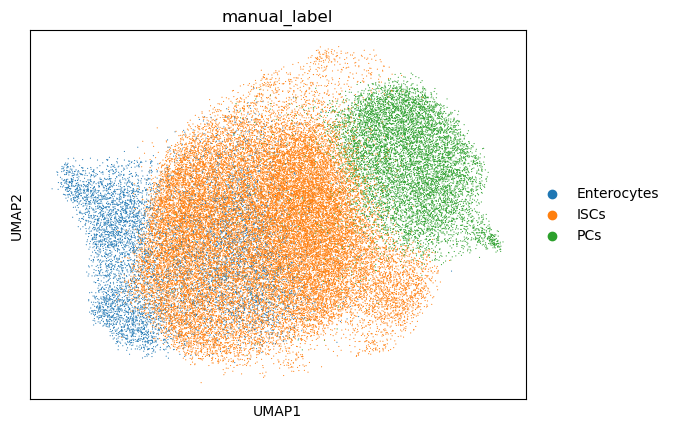

In [9]:
sc.pl.umap(d2_dz_clustered, color = 'manual_label')

#### Save our new label to the manual_labelled folder

In [10]:
sc.write('manual_labelled/d2_dz_manual_labels.h5ad', d2_dz_clustered)

In [11]:
# make sure it's categorical
d2_dz_clustered.obs["manual_label"] = d2_dz_clustered.obs["manual_label"].astype("category")

# add the new category
d2_dz_clustered.obs["manual_label"] = (
    d2_dz_clustered.obs["manual_label"]
    .cat.add_categories(["Proliferating PCs"])
)



In [12]:
def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

In [13]:
# Proliferating PCs: cluster 3 AND MKI67+
mki67_pos = gene_expr_bool(d2_dz_clustered, "MKI67")
mask_cluster2 = d2_dz_clustered.obs["leiden"] == "2"
mask_prolif_pcs = mask_cluster2 & mki67_pos
d2_dz_clustered.obs.loc[mask_prolif_pcs, "manual_label"] = "Proliferating PCs"

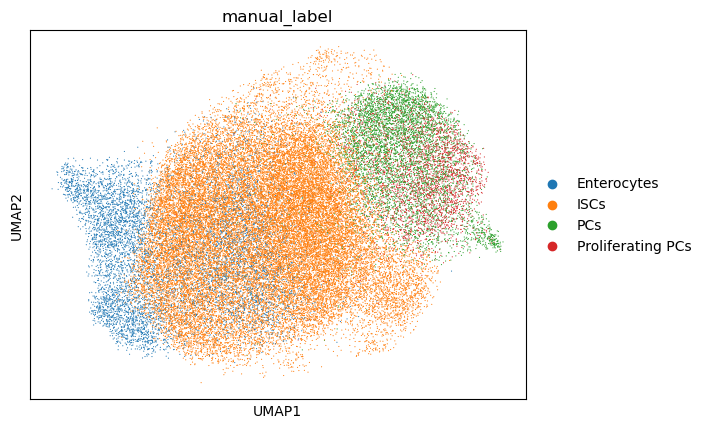

In [14]:
sc.pl.umap(d2_dz_clustered, color = 'manual_label')

In [15]:
sc.write('manual_labelled/d2_dz_manual_labels.h5ad', d2_dz_clustered)

### Plot the markers by cluster

sc.pl.dotplot(
    adata,
    filtered_markers,              # dict[group] = list of genes
    groupby=cluster_key,
    dendrogram=True,               # uses the sc.tl.dendrogram result
    standard_scale="var",          # scale per gene for comparability
    mean_only_expressed=True,      # makes size reflect % expressing, color = mean
    swap_axes=False,               # clusters on x-axis (set True to flip)
    show=False,
    colorbar_title="scaled\nexpression",
    figsize=(8, 4)
)
# Save exactly like Scanpy expects (relative to sc.settings.figdir if set)
sc.pl.dotplot(
    adata,
    filtered_markers,
    groupby=cluster_key,
    dendrogram=True,
    standard_scale="var",
    mean_only_expressed=True,
    show=False,
    save="_markers_by_leiden_dotplot.pdf"   # yields e.g. 'figures/dotplot_markers_by_leiden_dotplot.pdf'
)


In [16]:
sc.pl.stacked_violin(
    adata,
    filtered_markers,
    groupby=cluster_key,
    dendrogram=True,
    scale="width",
    swap_axes=False,
    show=False,
    figsize=(8, 6)
)
sc.pl.stacked_violin(
    adata,
    filtered_markers,
    groupby=cluster_key,
    dendrogram=True,
    scale="width",
    swap_axes=False,
    show=False,
    save="_markers_by_leiden_violin.pdf"
)


NameError: name 'adata' is not defined